# Astronomy Application

We apply our constrained empirical Bayes (EB) denoising methods to an astronomy data set, denoising the latent distribution of chemical abundances for a catalog of red-clump stars. We focus on the Oxygen–Iron and Nitrogen–Iron relative abundances ([O/Fe] and [N/Fe]) and model each star's true abundances as a latent variable observed through a bivariate heteroskedastic Gaussian measurement-error likelihood.

The notebook is organized into three parts: setting up the data, computing the EB denoisers, and plotting the results. The final figure reproduces the astronomy figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.GLMixture import *
import numpy as np
import pandas as pd
import pickle
import cvxpy as cp
import matplotlib.pyplot as plt
import random
import itertools
from heapq import nlargest
from scipy.linalg import inv, sqrtm
from matplotlib.path import Path
import matplotlib.patches as patches
import scipy.stats as stats
from scipy.spatial import distance_matrix
import ot

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Set up data

Our data is taken from the Apache Point Observatory Galactic Evolution Experiment (APOGEE) survey. The raw catalog is cast into the appropriate form in `data/make_astronomy_dataset.ipynb`, and the result is saved to a `.pkl` file that we load below. Each row records a star's measured [O/Fe] and [N/Fe] values together with the known precision (inverse variance) of each measurement.

In [2]:
chemicals = np.load('data/astronomy_data.pkl', allow_pickle=True)
chemicals

,O_FE_val,N_FE_val,O_FE_prec,N_FE_prec
0,0.325537,-0.008926,285.394775,748.162964
1,0.332795,0.067611,167.249359,411.257019
2,0.289167,0.178170,185.307648,496.124847
3,0.335026,-0.075908,230.855621,436.105286
4,0.158819,-0.052417,232.461884,477.688843
...,...,...,...,...
1995,0.256959,0.072567,180.981567,351.372498
1996,0.172650,0.182612,252.910034,682.914795
1997,0.319162,-0.013716,349.528473,952.185364
1998,0.140728,0.243737,350.282776,827.997986


In [3]:
# Z: observed [O/Fe], [N/Fe] pairs; Sigma: per-star measurement variances (1 / precision)
Z = np.vstack([chemicals['O_FE_val'].values,chemicals['N_FE_val'].values]).T
Sigma = 1./np.vstack([chemicals['O_FE_prec'].values,chemicals['N_FE_prec'].values]).T
n = Z.shape[0]
np.random.seed(321)

For the smooth NPMLE we impose a lower bound (a "smoothing floor") on the variance of each Gaussian mixture component. Here we fix this floor to `tau2_x = tau2_y = 0.0025` and plot it (red line) against the histograms of the observed measurement variances in each coordinate, confirming that it sits at a small quantile of the observed variances.

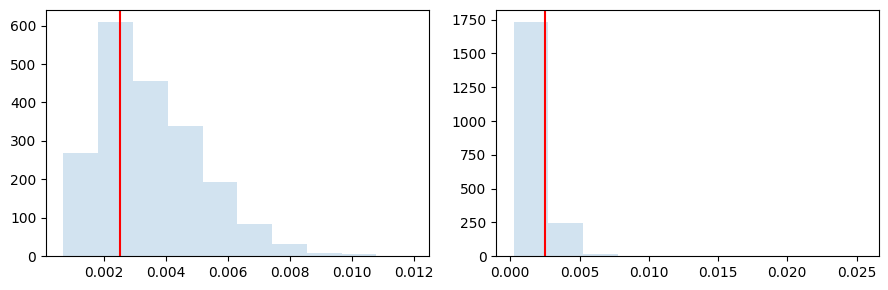

In [4]:
tau2_x = 0.0025
tau2_y = 0.0025

fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(9,3))

ax[0].hist(Sigma[:,0], alpha=0.2)
ax[0].axvline(tau2_x,color='red')

ax[1].hist(Sigma[:,1], alpha=0.2)
ax[1].axvline(tau2_y,color='red')

plt.tight_layout()
plt.show()

## Compute denoisers

We now compute the three EB denoisers of interest: the unconstrained denoiser, the (marginal) variance-constrained denoiser, and the (marginal) distribution-constrained denoiser. The unconstrained denoiser is obtained from the `npeb` package by fitting the smooth NPMLE, which we implement by artificially inflating the measurement variances by the smoothing floor chosen above.

### Unconstrained empirical Bayes

We fit the smooth NPMLE and form the unconstrained EB posterior-mean denoiser $\hat{\delta}_{\mathcal{B}}$.

In [5]:
Tau = np.vstack([tau2_x*np.ones(n), tau2_y*np.ones(n)]).T
eb_model = GLMixture(prec_type='diagonal')
eb = eb_model.fit(Z,1./(Sigma + Tau))

In [6]:
post_means = eb_model.posterior_mean(Z, 1./(Sigma + Tau))
eb = np.zeros_like(Z)
eb[:,0] = (1./tau2_x) * Z[:,0] / (1./tau2_x + 1./Sigma[:,0]) + (1./Sigma[:,0]) * post_means[:,0] / (1./tau2_x + 1./Sigma[:,0])
eb[:,1] = (1./tau2_y) * Z[:,1] / (1./tau2_y + 1./Sigma[:,1]) + (1./Sigma[:,1]) * post_means[:,1] / (1./tau2_y + 1./Sigma[:,1])

### Variance-constrained empirical Bayes

We rescale $\hat{\delta}_{\mathcal{B}}$ by the Bures–Wasserstein optimal-transport map that matches the covariance of the denoised data to the estimated covariance of the latent variables, giving $\hat{\delta}_{\mathcal{MVCB}}$ (Algorithm 1).

In [7]:
eb_mean = np.mean(eb,axis=0)
M_hat = (eb-eb_mean).T@(eb-eb_mean)/n
at, wt = eb_model.get_params()
mu_hat = np.sum(at * wt.reshape(-1,1), axis=0)
A_hat = np.diag([tau2_x,tau2_y]) + (at - mu_hat).T @ np.diag(wt) @ (at - mu_hat)
transport_hat = inv(sqrtm(M_hat))@sqrtm(sqrtm(M_hat)@A_hat@sqrtm(M_hat))@inv(sqrtm(M_hat))
emvcb = (eb - eb_mean)@transport_hat + mu_hat

In [8]:
transport_hat

array([[1.06314624, 0.04056488],
       [0.04056488, 1.19318425]])

### Distribution-constrained empirical Bayes

We solve the discretized optimal-transport problem coupling the denoised data to the estimated latent distribution $\hat{G}_n$, and take its barycentric projection to obtain $\hat{\delta}_{\mathcal{MDCB}}$ (Algorithm 2).

In [9]:
# epss = np.logspace(-10,0)
# best_lik = -np.inf
# best_eps = None
# for eps in epss:
#     at_tmp = at[wt > eps]
#     wt_tmp = wt[wt > eps]/np.sum(wt[wt > eps])
#     eb_model.set_params(at_tmp, wt_tmp)
#     lik = eb_model.score(Z, 1./(Sigma + Tau))
#     #print(len(wt_tmp), eps, lik)
#     if lik > best_lik:
#         best_lik = lik
#         best_eps = eps

# at = at[wt > best_eps]
# wt = wt[wt > best_eps]/np.sum(wt[wt > best_eps])

In [10]:
# Atom-pruning threshold selected by the (commented-out) likelihood search above.
best_eps = 2.8117686979742307e-08
best_eps

2.8117686979742307e-08

In [11]:
# NOTE: Longest-running cell in this notebook. It solves a large optimal-transport
# linear program and dominates the ~18 min runtime (see the README).
k = 300
Eta_x = np.linspace(-0.1,0.6,k)
Eta_y = np.linspace(-0.1,0.4,k)
Eta = np.array(list(itertools.product(Eta_x,Eta_y)))

Eta_wt = np.zeros(k**2)
m = len(wt)
for i in range(m):
    rv = stats.multivariate_normal(mean=at[i,:], cov=[tau2_x, tau2_y])
    probs = rv.pdf(Eta)
    Eta_wt += probs * wt[i] / np.sum(probs)
Eta_wt = Eta_wt/np.sum(Eta_wt)

# squared-distance cost, then solve the OT problem from the denoised data to the grid
C_hat = distance_matrix(eb, Eta)**2
pi = ot.emd(np.ones(n)/n, Eta_wt, C_hat, numItermax=1e6)

# barycentric projection of the optimal coupling
emdcb = np.zeros((n,2))
for i in range(n):
    emdcb[i,:] = (pi[i,:].reshape(1,-1)@Eta)/np.sum(pi[i,:])

## Plot

Finally, we plot the raw observations alongside the unconstrained, variance-constrained, and distribution-constrained EB denoised data sets.

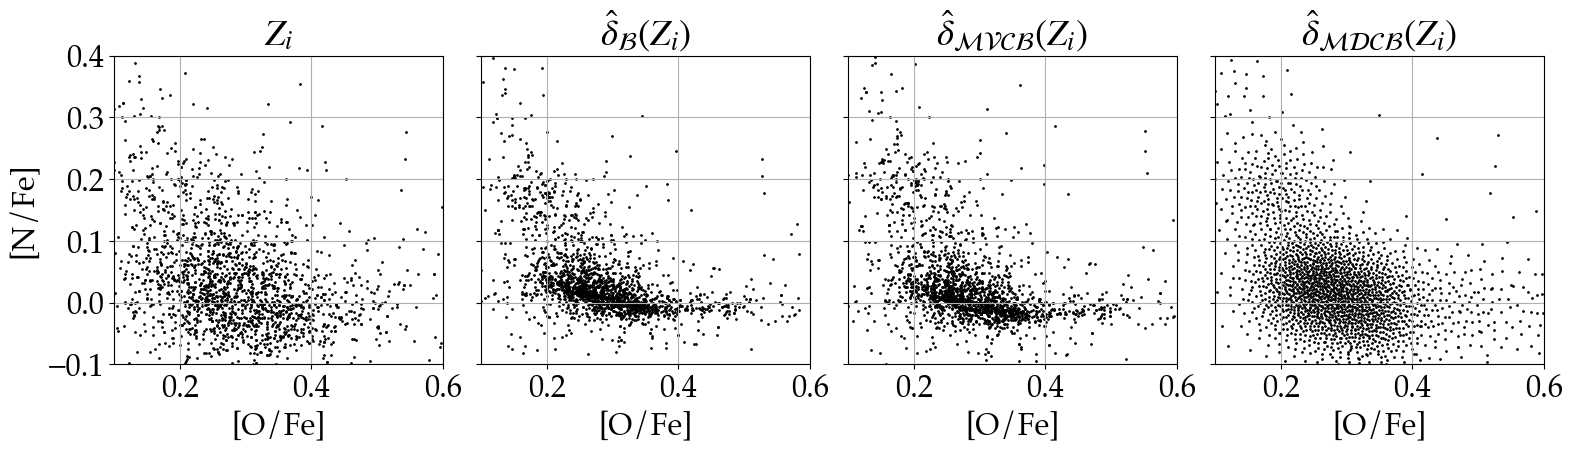

In [12]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

fig, ax = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(16,5))

xmin, xmax = 0.1, 0.6,
ymin, ymax = -0.1, 0.4
Z_alpha = 1.0

ax[0].scatter(Z[:,0],Z[:,1], s=1, alpha = Z_alpha, color='black')
ax[0].set_title('$Z_i$')
ax[0].grid()

ax[1].scatter(eb[:,0],eb[:,1], s=1, alpha = Z_alpha, color='black')
ax[1].set_title('$\\hat{\\delta}_{\\mathcal{B}}(Z_i)$')
ax[1].grid()

ax[2].scatter(emvcb[:,0],emvcb[:,1], s=1, alpha = Z_alpha, color='black')
ax[2].set_title('$\\hat{\\delta}_{\\mathcal{MVCB}}(Z_i)$')
ax[2].grid()

ax[3].scatter(emdcb[:,0],emdcb[:,1], s=1, alpha = Z_alpha, color='black')
ax[3].set_title('$\\hat{\\delta}_{\\mathcal{MDCB}}(Z_i)$')
ax[3].grid()

ax[0].set_xlabel('[O/Fe]')
ax[1].set_xlabel('[O/Fe]')
ax[2].set_xlabel('[O/Fe]')
ax[3].set_xlabel('[O/Fe]')
ax[0].set_ylabel('[N/Fe]')

plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.savefig('figs/astronomy.pdf')
plt.savefig('figs/astronomy.png')
plt.show()